In [1]:
import torch
torch.set_grad_enabled(False)
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
from hydra.utils import instantiate
from pathlib import Path
import os
from tqdm.notebook import tqdm
from copy import deepcopy
import pandas as pd

from plbregression.noise import add_microscopic_noise

In [ ]:
# zbiory danych ze stałym slice_poition=0 i losowym slice_position
DATASETS = {
    "slice_position_0": "dataset_01_20260223",
    "slice_position_random_val": "dataset_02_20260401_N10000",
}

N_SAMPLES = 100
noise_strengths = np.linspace(0, 1, 21)

parameters_ranges = { # takie same dla obu zbiorów danych
    "uc_scale_ab": (50,120),
    "channel_vol_prop": (0.15, 0.5),
}

parameters_standardization_constants = { # takie same dla obu zbiorów danych
    "uc_scale_ab": {
        "mean": 85.03442,
        "std": 20.201132,
    },
    "channel_vol_prop": {
        "mean": 0.325,
        "std": 0.1,
    },
}

# sieć zwraca parametry po normalizacji do rozkładu ze średnią 0 i odchyleniem standardowym 1, więc trzeba je destandardyzować, a potem znormalizować do zakresu 0-1
def destandardize_params(standardized_params):
    return standardized_params * np.array([parameters_standardization_constants[name]["std"] for name in ['uc_scale_ab', 'channel_vol_prop']]) + np.array([parameters_standardization_constants[name]["mean"] for name in ['uc_scale_ab', 'channel_vol_prop']])

def normalize_params(params):
    "to 0-1 range"
    return (params - np.array([parameters_ranges[name][0] for name in ['uc_scale_ab', 'channel_vol_prop']])) / np.array([parameters_ranges[name][1] - parameters_ranges[name][0] for name in ['uc_scale_ab', 'channel_vol_prop']])


## 1. Stałe `slice_position` 

### 1.1 Przygotowanie modelu

In [27]:
run_dir = Path("runs/exp_01_20260331_170514") #"runs/exp_01_20260331_170514") #runs/exp_01_20260309_132112")
config = OmegaConf.load(run_dir / "config.yaml")
# lateset "checkpoint*pth" in run_dir
checkpoint_path = sorted(run_dir.glob("checkpoint*.pth"), key=os.path.getctime)[-1]
print(f"Loading model from checkpoint: {checkpoint_path}")

model = instantiate(config.model).eval().to(config.training.device)
model.load_state_dict(torch.load(checkpoint_path, map_location=config.training.device))

Loading model from checkpoint: runs/exp_01_20260331_170514/checkpoint_epoch_1_batch_0.pth


<All keys matched successfully>

## Prygotowanie danych

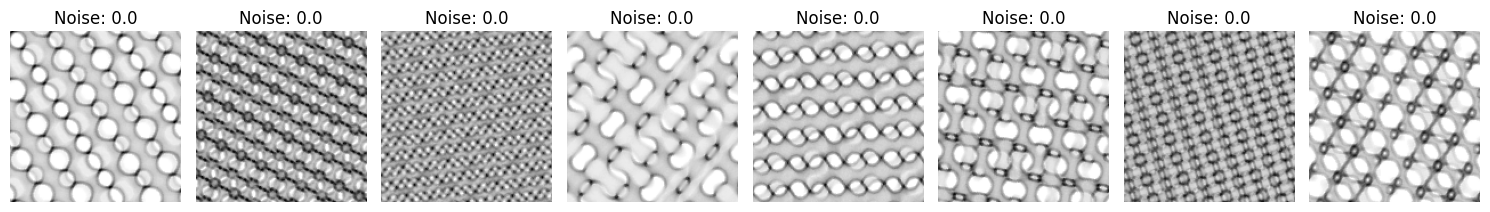

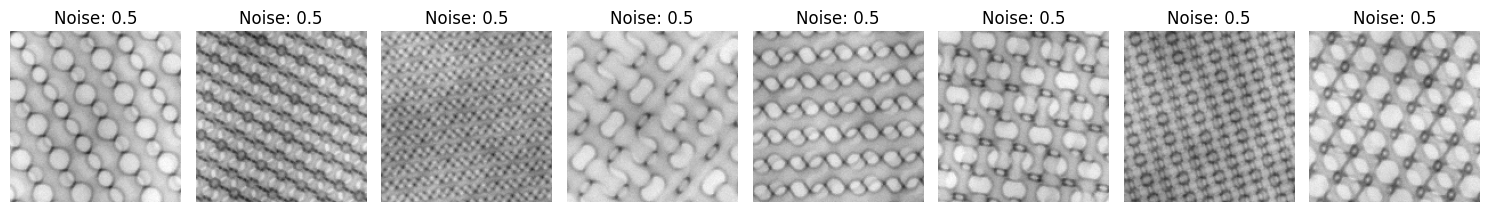

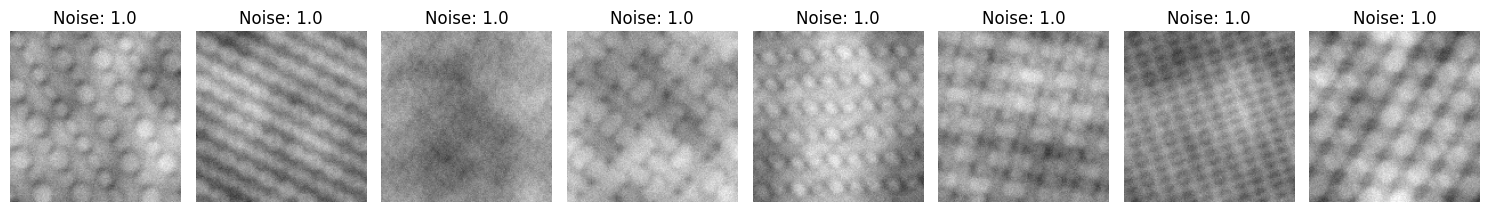

In [28]:
dataset_config = {
    "_target_": "plbregression.dataset.PLBDataset",
    "data_dir": f"../../data_generation/{DATASETS['slice_position_0']}",
    "indices": np.arange(config.data.indices, config.data.indices + N_SAMPLES), #skip samples used for training
    "use_params": ['uc_scale_ab', 'channel_vol_prop', 'h', 'k', 'l'],
    "return_tensors": False,
    "params_transforms": [
        {
            "_target_": "plbregression.dataset.ParamsNormalizer",
            "means": [parameters_standardization_constants[name]["mean"] for name in ['uc_scale_ab', 'channel_vol_prop']],
            "stds": [parameters_standardization_constants[name]["std"] for name in ['uc_scale_ab', 'channel_vol_prop']],
            "indices_to_use": (0,1)
        },
        {
            "_target_": "plbregression.dataset.HKLToUnitVector",
            "indices_to_use": (2, 3, 4)
        }
    ],
    "transforms": [
        {
            "_target_": "plbregression.dataset.RandomRotatedShiftedCrop",
            "size": 150,
            "interpolation": "cubic"
        },
        # {
        #     "_target_": "plbregression.dataset.MicroscopicNoise",
        #     "strength": 0.0
        # },
    ],
}
datatset = instantiate(dataset_config)
dataloader = torch.utils.data.DataLoader(datatset, batch_size=8, shuffle=False)
images_noise0, params = next(iter(dataloader))
for noise_strength in [0.0, 0.5, 1.0]:
    images_noisy = torch.from_numpy(add_microscopic_noise(images_noise0.squeeze(0).numpy(), strength=noise_strength)).float().unsqueeze(1) / 255.0
    preds = model(images_noisy.to(config.training.device)).cpu().numpy()
    fig, axes = plt.subplots(1, 8, figsize=(15, 5))
    for i in range(8):
        axes[i].imshow(images_noisy[i, 0], cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f"Noise: {noise_strength}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


## Pętla

In [29]:
dataloader = torch.utils.data.DataLoader(datatset, batch_size=N_SAMPLES, shuffle=False)
images_noise0, params = next(iter(dataloader))

# param_means = np.array(config.data.training.params_transforms[0].means)
# param_stds = np.array(config.data.training.params_transforms[0].stds)

uc_scale_ab_for_noise = []
channel_vol_prop_for_noise = []
direction_deg_for_noise = []

for noise_strength in tqdm(noise_strengths):
    images_noisy = torch.from_numpy(add_microscopic_noise(images_noise0.squeeze(0).numpy(), strength=noise_strength)).float().unsqueeze(1) / 255.0
    preds = model(images_noisy.to(config.training.device)).cpu().numpy()
    
    normalized_params_preds = normalize_params(destandardize_params(preds[:, :2]))
    normalized_params_gt = normalize_params(destandardize_params(params.numpy()[:, :2]))
    normalized_params_residuals = normalized_params_preds - normalized_params_gt
    normalized_params_se = normalized_params_residuals**2
    normalized_params_mse = np.mean(normalized_params_se, axis=0)
    normalized_params_quantiles = np.quantile(np.abs(normalized_params_residuals), [0.1, 0.25, 0.75, 0.9], axis=0)

    uc_scale_ab_for_noise.append({
        "noise_strength": noise_strength,
        "MSE": normalized_params_mse[0],
        "Q1": normalized_params_quantiles[0, 0],
        "Q25": normalized_params_quantiles[1, 0],
        "Q75": normalized_params_quantiles[2, 0],
        "Q9": normalized_params_quantiles[3, 0],
        "MAE": np.mean(np.abs(normalized_params_residuals[:, 0])),
        "RMSE": np.mean(normalized_params_se[:, 0])**0.5
    })

    channel_vol_prop_for_noise.append({
        "noise_strength": noise_strength,
        "MSE": normalized_params_mse[1],
        "Q1": normalized_params_quantiles[0, 1],
        "Q25": normalized_params_quantiles[1, 1],
        "Q75": normalized_params_quantiles[2, 1],
        "Q9": normalized_params_quantiles[3, 1],
        "MAE": np.mean(np.abs(normalized_params_residuals[:, 1])),
        "RMSE": np.mean(normalized_params_se[:, 1])**0.5
    })
    
    normalized_direction = preds[:, 2:] / np.linalg.norm(preds[:, 2:], axis=1, keepdims=True)
    true_direction = params.numpy()[:, 2:] / np.linalg.norm(params.numpy()[:, 2:], axis=1, keepdims=True)
    direction_residuals_deg = np.arccos(np.clip(np.sum(normalized_direction * true_direction, axis=1), -1.0, 1.0)) * 180 / np.pi
    direction_residuals_squared_deg = direction_residuals_deg**2

    direction_residuals_quantiles = np.quantile(direction_residuals_deg, [0.1, 0.25, 0.75, 0.9])

    direction_deg_for_noise.append({
        "noise_strength": noise_strength,
        "RMSE": np.mean(direction_residuals_deg**2)**0.5, # convert MSE to RMSE
        "ME": np.mean(direction_residuals_deg),
        "Q1": direction_residuals_quantiles[0],
        "Q25": direction_residuals_quantiles[1],
        "Q75": direction_residuals_quantiles[2],
        "Q9": direction_residuals_quantiles[3]
    })
uc_scale_ab_for_noise = pd.DataFrame(uc_scale_ab_for_noise)
channel_vol_prop_for_noise = pd.DataFrame(channel_vol_prop_for_noise)
direction_deg_for_noise = pd.DataFrame(direction_deg_for_noise)

uc_scale_ab_for_noise.to_csv(run_dir / "uc_scale_ab_for_noise.csv", index=False)
channel_vol_prop_for_noise.to_csv(run_dir / "channel_vol_prop_for_noise.csv", index=False)
direction_deg_for_noise.to_csv(run_dir / "direction_deg_for_noise.csv", index=False)





  0%|          | 0/21 [00:00<?, ?it/s]

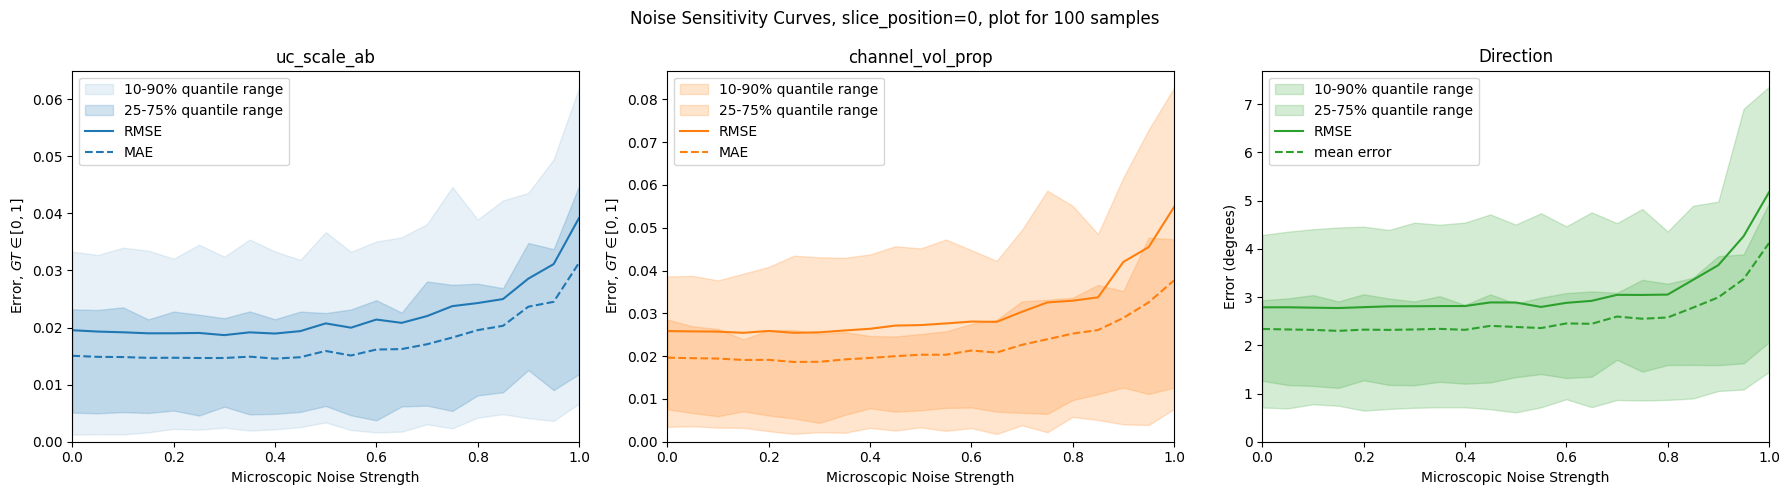

In [30]:
uc_scale_ab_for_noise = pd.read_csv(run_dir / "uc_scale_ab_for_noise.csv")
channel_vol_prop_for_noise = pd.read_csv(run_dir / "channel_vol_prop_for_noise.csv")
direction_deg_for_noise = pd.read_csv(run_dir / "direction_deg_for_noise.csv")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].fill_between(noise_strengths, uc_scale_ab_for_noise['Q1'], uc_scale_ab_for_noise['Q9'], color='C0', alpha=0.1, label='10-90% quantile range')
axs[0].fill_between(noise_strengths, uc_scale_ab_for_noise['Q25'], uc_scale_ab_for_noise['Q75'], color='C0', alpha=0.2, label='25-75% quantile range')
axs[0].plot(noise_strengths, uc_scale_ab_for_noise['RMSE'], label='RMSE', color='C0')
axs[0].plot(noise_strengths, uc_scale_ab_for_noise['MAE'], label='MAE', color='C0', linestyle='--')
axs[0].set_xlabel('Microscopic Noise Strength')
axs[0].set_ylabel('Error, $GT \in [0,1]$')
axs[0].set_title('uc_scale_ab')
axs[0].legend() 

axs[1].fill_between(noise_strengths, channel_vol_prop_for_noise['Q1'], channel_vol_prop_for_noise['Q9'], color='C1', alpha=0.2, label='10-90% quantile range')
axs[1].fill_between(noise_strengths, channel_vol_prop_for_noise['Q25'], channel_vol_prop_for_noise['Q75'], color='C1', alpha=0.2, label='25-75% quantile range')
axs[1].plot(noise_strengths, channel_vol_prop_for_noise['RMSE'], label='RMSE', color='C1')
axs[1].plot(noise_strengths, channel_vol_prop_for_noise['MAE'], label='MAE', color='C1', linestyle='--')
axs[1].set_xlabel('Microscopic Noise Strength')
axs[1].set_ylabel('Error, $GT \in [0,1]$')
axs[1].set_title('channel_vol_prop')
axs[1].legend() 

axs[2].fill_between(noise_strengths, direction_deg_for_noise['Q1'], direction_deg_for_noise['Q9'], color='C2', alpha=0.2, label='10-90% quantile range')
axs[2].fill_between(noise_strengths, direction_deg_for_noise['Q25'], direction_deg_for_noise['Q75'], color='C2', alpha=0.2, label='25-75% quantile range')
axs[2].plot(noise_strengths, direction_deg_for_noise['RMSE'], label='RMSE', color='C2')
axs[2].plot(noise_strengths, direction_deg_for_noise['ME'], label='mean error', color='C2', linestyle='--')
axs[2].set_xlabel('Microscopic Noise Strength')
axs[2].set_ylabel('Error (degrees)')
axs[2].set_title('Direction')
axs[2].legend()

for ax in axs:
    ax.set_ylim(0, None)
    ax.set_xlim(0, 1)

fig.suptitle(f'Noise Sensitivity Curves, slice_position=0, plot for {N_SAMPLES} samples')

plt.tight_layout()

plt.savefig(run_dir / "noise_sensitivity_curves.png")

## 2. Variable slice position

Loading model from checkpoint: runs/exp_01_20260402_085914/checkpoint_epoch_1_batch_900.pth


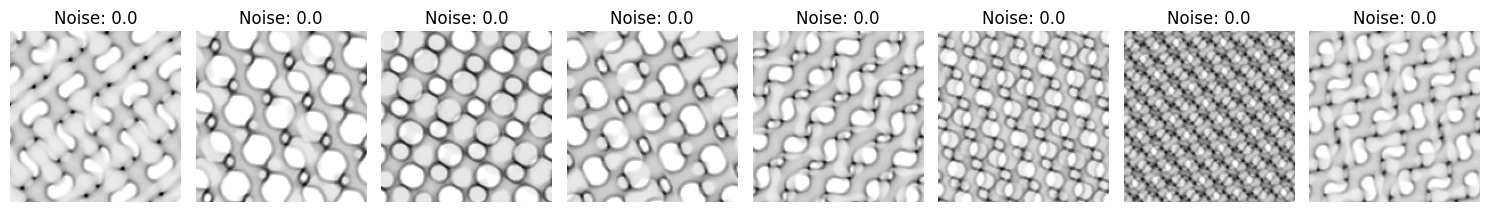

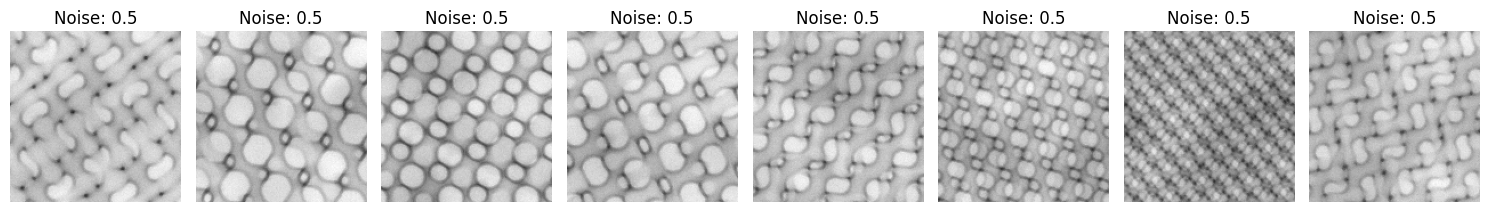

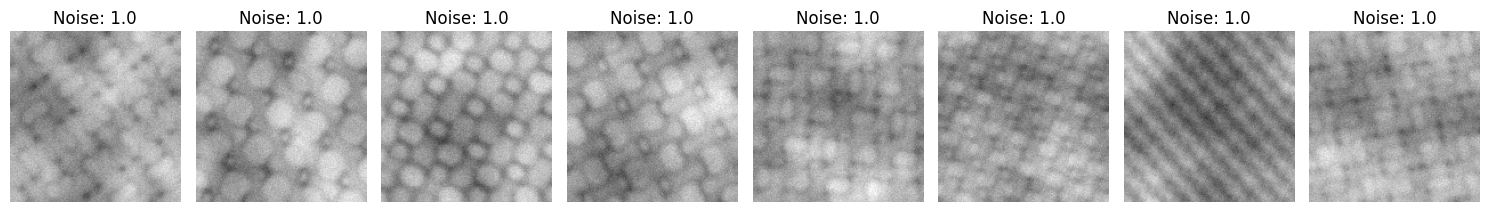

In [31]:
run_dir = Path("runs/exp_01_20260402_085914") #"runs/exp_01_20260331_170514") #runs/exp_01_20260309_132112")
config = OmegaConf.load(run_dir / "config.yaml")
# lateset "checkpoint*pth" in run_dir
checkpoint_path = sorted(run_dir.glob("checkpoint*.pth"), key=os.path.getctime)[-1]
print(f"Loading model from checkpoint: {checkpoint_path}")

model = instantiate(config.model).eval().to(config.training.device)
model.load_state_dict(torch.load(checkpoint_path, map_location=config.training.device))

dataset_config = {
    "_target_": "plbregression.dataset.PLBDataset",
    "data_dir": f"../../data_generation/{DATASETS['slice_position_random_val']}",
    "indices": N_SAMPLES, 
    "use_params": ['uc_scale_ab', 'channel_vol_prop', 'h', 'k', 'l'],
    "return_tensors": False,
    "params_transforms": [
        {
            "_target_": "plbregression.dataset.ParamsNormalizer",
            "means": [85.03442   ,  0.32531843],
            "stds": [20.201132  ,  0.10095225],
            "indices_to_use": (0,1)
        },
        {
            "_target_": "plbregression.dataset.HKLToUnitVector",
            "indices_to_use": (2, 3, 4)
        }
    ],
    "transforms": [
        {
            "_target_": "plbregression.dataset.RandomRotatedShiftedCrop",
            "size": 150,
            "interpolation": "cubic"
        },
        # {
        #     "_target_": "plbregression.dataset.MicroscopicNoise",
        #     "strength": 0.0
        # },
    ],
}
datatset = instantiate(dataset_config)
dataloader = torch.utils.data.DataLoader(datatset, batch_size=8, shuffle=False)
images_noise0, params = next(iter(dataloader))
for noise_strength in [0.0, 0.5, 1.0]:
    images_noisy = torch.from_numpy(add_microscopic_noise(images_noise0.squeeze(0).numpy(), strength=noise_strength)).float().unsqueeze(1) / 255.0
    preds = model(images_noisy.to(config.training.device)).cpu().numpy()
    fig, axes = plt.subplots(1, 8, figsize=(15, 5))
    for i in range(8):
        axes[i].imshow(images_noisy[i, 0], cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f"Noise: {noise_strength}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


In [32]:
dataloader = torch.utils.data.DataLoader(datatset, batch_size=N_SAMPLES, shuffle=False)
images_noise0, params = next(iter(dataloader))

# param_means = np.array(config.data.training.params_transforms[0].means)
# param_stds = np.array(config.data.training.params_transforms[0].stds)

uc_scale_ab_for_noise = []
channel_vol_prop_for_noise = []
direction_deg_for_noise = []

for noise_strength in tqdm(noise_strengths):
    images_noisy = torch.from_numpy(add_microscopic_noise(images_noise0.squeeze(0).numpy(), strength=noise_strength)).float().unsqueeze(1) / 255.0
    preds = model(images_noisy.to(config.training.device)).cpu().numpy()
    
    normalized_params_preds = normalize_params(destandardize_params(preds[:, :2]))
    normalized_params_gt = normalize_params(destandardize_params(params.numpy()[:, :2]))
    normalized_params_residuals = normalized_params_preds - normalized_params_gt
    normalized_params_se = normalized_params_residuals**2
    normalized_params_mse = np.mean(normalized_params_se, axis=0)
    normalized_params_quantiles = np.quantile(np.abs(normalized_params_residuals), [0.1, 0.25, 0.75, 0.9], axis=0)

    uc_scale_ab_for_noise.append({
        "noise_strength": noise_strength,
        "MSE": normalized_params_mse[0],
        "Q1": normalized_params_quantiles[0, 0],
        "Q25": normalized_params_quantiles[1, 0],
        "Q75": normalized_params_quantiles[2, 0],
        "Q9": normalized_params_quantiles[3, 0],
        "MAE": np.mean(np.abs(normalized_params_residuals[:, 0])),
        "RMSE": np.mean(normalized_params_se[:, 0])**0.5
    })

    channel_vol_prop_for_noise.append({
        "noise_strength": noise_strength,
        "MSE": normalized_params_mse[1],
        "Q1": normalized_params_quantiles[0, 1],
        "Q25": normalized_params_quantiles[1, 1],
        "Q75": normalized_params_quantiles[2, 1],
        "Q9": normalized_params_quantiles[3, 1],
        "MAE": np.mean(np.abs(normalized_params_residuals[:, 1])),
        "RMSE": np.mean(normalized_params_se[:, 1])**0.5
    })
    
    normalized_direction = preds[:, 2:] / np.linalg.norm(preds[:, 2:], axis=1, keepdims=True)
    true_direction = params.numpy()[:, 2:] / np.linalg.norm(params.numpy()[:, 2:], axis=1, keepdims=True)
    direction_residuals_deg = np.arccos(np.clip(np.sum(normalized_direction * true_direction, axis=1), -1.0, 1.0)) * 180 / np.pi
    direction_residuals_squared_deg = direction_residuals_deg**2

    direction_residuals_quantiles = np.quantile(direction_residuals_deg, [0.1, 0.25, 0.75, 0.9])

    direction_deg_for_noise.append({
        "noise_strength": noise_strength,
        "RMSE": np.mean(direction_residuals_deg**2)**0.5, # convert MSE to RMSE
        "ME": np.mean(direction_residuals_deg),
        "Q1": direction_residuals_quantiles[0],
        "Q25": direction_residuals_quantiles[1],
        "Q75": direction_residuals_quantiles[2],
        "Q9": direction_residuals_quantiles[3]
    })

uc_scale_ab_for_noise = pd.DataFrame(uc_scale_ab_for_noise)
channel_vol_prop_for_noise = pd.DataFrame(channel_vol_prop_for_noise)
direction_deg_for_noise = pd.DataFrame(direction_deg_for_noise)

uc_scale_ab_for_noise.to_csv(run_dir / "uc_scale_ab_for_noise.csv", index=False)
channel_vol_prop_for_noise.to_csv(run_dir / "channel_vol_prop_for_noise.csv", index=False)
direction_deg_for_noise.to_csv(run_dir / "direction_deg_for_noise.csv", index=False)


  0%|          | 0/21 [00:00<?, ?it/s]

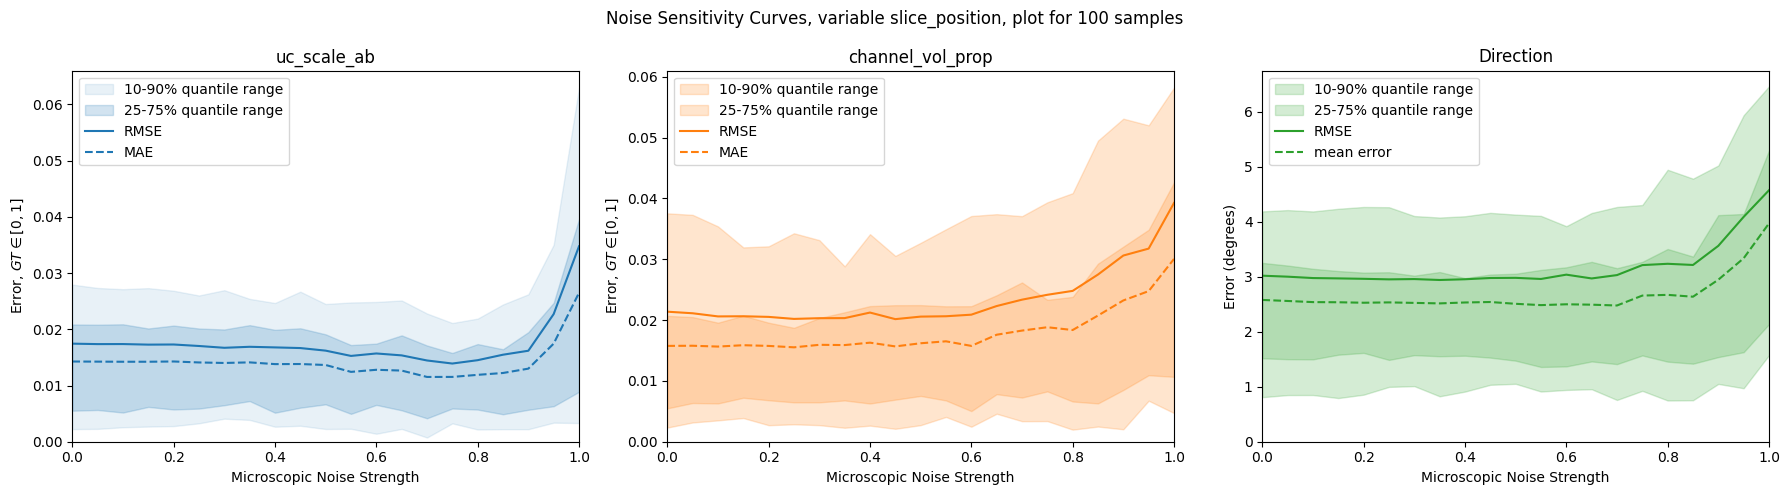

In [33]:
uc_scale_ab_for_noise = pd.read_csv(run_dir / "uc_scale_ab_for_noise.csv")
channel_vol_prop_for_noise = pd.read_csv(run_dir / "channel_vol_prop_for_noise.csv")
direction_deg_for_noise = pd.read_csv(run_dir / "direction_deg_for_noise.csv")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].fill_between(noise_strengths, uc_scale_ab_for_noise['Q1'], uc_scale_ab_for_noise['Q9'], color='C0', alpha=0.1, label='10-90% quantile range')
axs[0].fill_between(noise_strengths, uc_scale_ab_for_noise['Q25'], uc_scale_ab_for_noise['Q75'], color='C0', alpha=0.2, label='25-75% quantile range')
axs[0].plot(noise_strengths, uc_scale_ab_for_noise['RMSE'], label='RMSE', color='C0')
axs[0].plot(noise_strengths, uc_scale_ab_for_noise['MAE'], label='MAE', color='C0', linestyle='--')
axs[0].set_xlabel('Microscopic Noise Strength')
axs[0].set_ylabel('Error, $GT \in [0,1]$')
axs[0].set_title('uc_scale_ab')
axs[0].legend() 

axs[1].fill_between(noise_strengths, channel_vol_prop_for_noise['Q1'], channel_vol_prop_for_noise['Q9'], color='C1', alpha=0.2, label='10-90% quantile range')
axs[1].fill_between(noise_strengths, channel_vol_prop_for_noise['Q25'], channel_vol_prop_for_noise['Q75'], color='C1', alpha=0.2, label='25-75% quantile range')
axs[1].plot(noise_strengths, channel_vol_prop_for_noise['RMSE'], label='RMSE', color='C1')
axs[1].plot(noise_strengths, channel_vol_prop_for_noise['MAE'], label='MAE', color='C1', linestyle='--')
axs[1].set_xlabel('Microscopic Noise Strength')
axs[1].set_ylabel('Error, $GT \in [0,1]$')
axs[1].set_title('channel_vol_prop')
axs[1].legend() 

axs[2].fill_between(noise_strengths, direction_deg_for_noise['Q1'], direction_deg_for_noise['Q9'], color='C2', alpha=0.2, label='10-90% quantile range')
axs[2].fill_between(noise_strengths, direction_deg_for_noise['Q25'], direction_deg_for_noise['Q75'], color='C2', alpha=0.2, label='25-75% quantile range')
axs[2].plot(noise_strengths, direction_deg_for_noise['RMSE'], label='RMSE', color='C2')
axs[2].plot(noise_strengths, direction_deg_for_noise['ME'], label='mean error', color='C2', linestyle='--')
axs[2].set_xlabel('Microscopic Noise Strength')
axs[2].set_ylabel('Error (degrees)')
axs[2].set_title('Direction')
axs[2].legend()

for ax in axs:
    ax.set_ylim(0, None)
    ax.set_xlim(0, 1)

fig.suptitle(f'Noise Sensitivity Curves, variable slice_position, plot for {N_SAMPLES} samples')

plt.tight_layout()

plt.savefig(run_dir / "noise_sensitivity_curves.png")
